## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm


import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))


from ml_force import MorrisLecar, MorrisLecarCurrent
from ml_force.utils import minmax_transform, z_transform
from ml_force.supervisors import LorenzAttractor
from ml_force.plots import plot_model
from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [3]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)

T = 20000
dt = 1e-1
t = np.arange(0, T, dt)
nt = t.size
# x = VanDerPol(T, dt, mu=1, tau=.02).generate(transient_time=500.0)
x = LorenzAttractor(T, dt, tau=.01).generate(transient_time=1000.0)

x = x.T
# sup = minmax_transform(x, zero_mean=True)
sup = z_transform(x)
print(sup.shape)

(200000, 3)


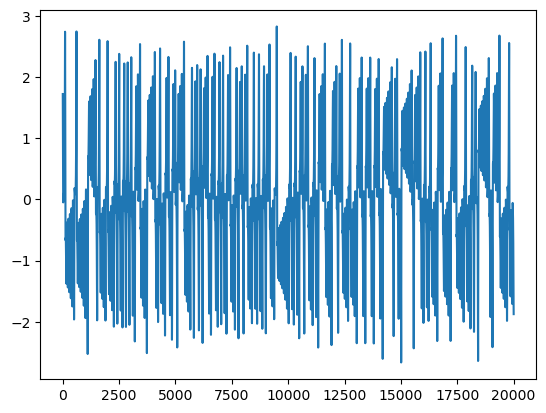

In [4]:
plt.plot(t, sup[:, 1])
plt.show()

# ML Conductance-based Model

In [5]:
NE = 4000
NI = 1000
N = NI + NE


# input current for I and E neurons
Ie = 65     # pA
Ii = 65     # pA
current = np.array([Ie] * NE + [Ii] * NI).reshape(N, 1)

# Parameter for the hippocampus neurons
hp_params = {
    "C": 2.0,
    "g_L": 2,
    "g_K": 8,
    "g_Ca": 4.0,
    "E_L": -60.0,
    "E_Ca": 120.0,
    "E_K": -80.0,
    "v1": -1.2,
    "v2": 18.0,
    "v3": 10.0,
    "v4": 17.4,
    "phi": 1/15.0,
}

Q = 150
lamda = 1.
gbar = 25
sparse = 0.01

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)
ml = None
try:
    ml = MorrisLecar(supervisor=sup, BIAS=current, T=T, dt=dt, 
                            # p_sparsity=sparse,
                            Ne=NE, Ni=NI, Q=Q, gbar=gbar, ridge_coeff=lamda, device=device,
                            # **hp_params
                            )
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

Using Device <cuda> for PyTorch computations...



In [7]:
# colors = plt.pcolormesh(ml.w.cpu().numpy(), cmap='viridis')
# plt.colorbar(colors)
# plt.show()

print(f"Mean: {ml.w.type(dtype=torch.float64).mean().item()}, \nSTD: {ml.w.type(dtype=torch.float64).std().item()}")
print(f"Max: {ml.w.type(dtype=torch.float64).max().item()}, \nMin: {ml.w.type(dtype=torch.float64).min().item()}")

Mean: 0.00039776, 
STD: 0.0199399549369218
Max: 1.0, 
Min: 0.0


In [8]:
# RLS params
# rls_stop = round(T * .6)
rls_start = 500
test_time = T * .5    # ms
rls_stop = T - test_time
rls_step = 20

memory_length = 5000    # ms
rls_gap = rls_step * dt
memory_coeff = memory_length / rls_gap
ff_coeff = 1 - 1 / memory_coeff

# ff_coeff = 1
ff_coeff

0.9996

In [9]:
save_path = os.path.join(os.getcwd(), "results", f"Q_{Q}_gbar_{gbar}_l_{lamda}_Ne_{NE}_Ni_{NI}")
os.makedirs(save_path, exist_ok=True)

def save_tensor(tensor, name):
    file_name = name + ".pt"
    torch.save(tensor, os.path.join(save_path, file_name))
    print(f"Saved {file_name} in {save_path}")

In [10]:
duration = 500
nt_transient = int(duration // dt)

n_neurons = 10
neurons = np.random.choice(N, n_neurons, replace=False)
print(neurons)

print(f"Transient Period: {duration} ms")
for i in tqdm(range(nt_transient)):
    ml.euler_step()

nt_train = int((T-test_time) // dt)
s_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
v_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
n_rec_train = torch.zeros((nt_train, n_neurons), device=device, dtype=torch.float32)
xhat_rec_train = torch.zeros((nt_train, sup.shape[1]), device=device, dtype=torch.float32)
dec_rec_train = torch.zeros((nt_train, n_neurons, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Training Period: {T-test_time} ms")
for i in tqdm(range(nt_train)):
    ml.euler_step()
    s_rec_train[i] = ml.s[neurons].ravel()
    v_rec_train[i] = ml.v[neurons].ravel()
    n_rec_train[i] = ml.n[neurons].ravel()
    xhat_rec_train[i] = ml.x_hat.ravel()
    dec_rec_train[i] = ml.dec[neurons]

    if i <= int(rls_stop // dt) and i % rls_step == 0:
        # ml.rls_ff(i, ff_coeff=ff_coeff)
        ml.rls(i)

[2764 4767 3814 3499 2735 3922 2701 1179  932  792]
Transient Period: 500 ms


100%|██████████| 4999/4999 [00:33<00:00, 149.24it/s]


Training Period: 10000.0 ms


100%|██████████| 99999/99999 [11:33<00:00, 144.10it/s]


In [11]:
save_tensor(ml.w, "weights")
save_tensor(s_rec_train, "s_rec_train")
save_tensor(v_rec_train, "v_rec_train")
save_tensor(n_rec_train, "n_rec_train")
save_tensor(xhat_rec_train, "xhat_rec_train")
save_tensor(dec_rec_train, "dec_rec_train")


Saved weights.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved s_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved v_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved n_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved xhat_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved dec_rec_train.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000


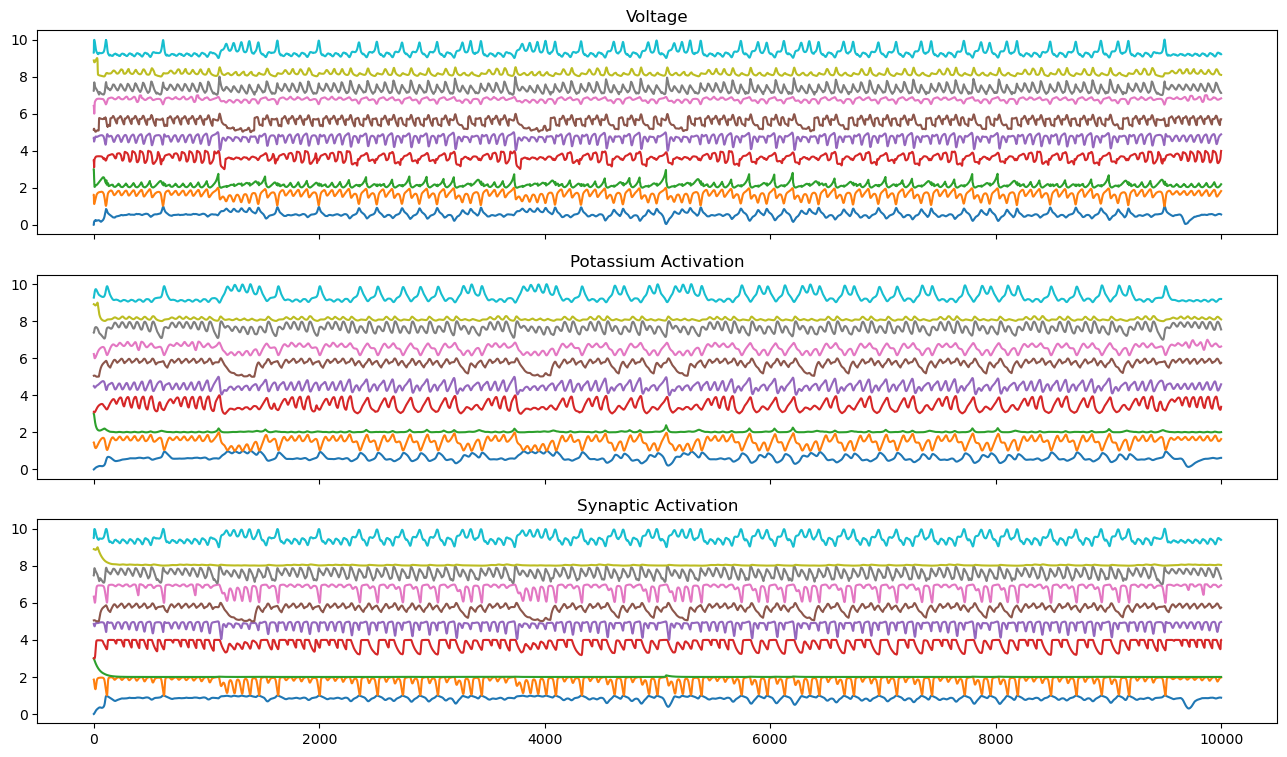

In [12]:
t_train = np.arange(nt_train) * dt

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_train, minmax_transform(v_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_train, minmax_transform(n_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_train, minmax_transform(s_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

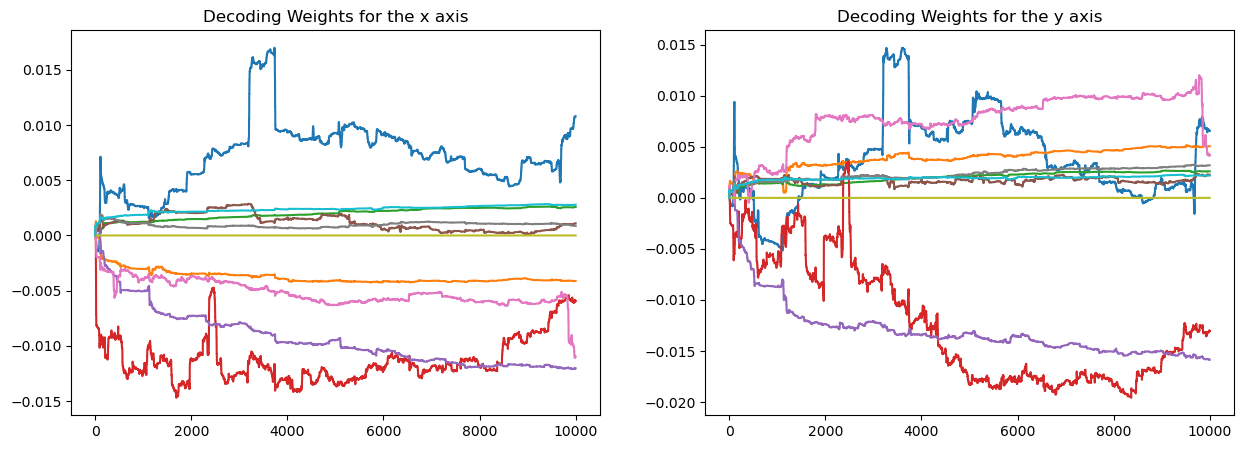

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, dec_rec_train[:, :, 0].cpu().numpy())
ax[0].set_title('Decoding Weights for the x axis')
ax[1].plot(t_train, dec_rec_train[:, :, 1].cpu().numpy())
ax[1].set_title('Decoding Weights for the y axis')
plt.show()

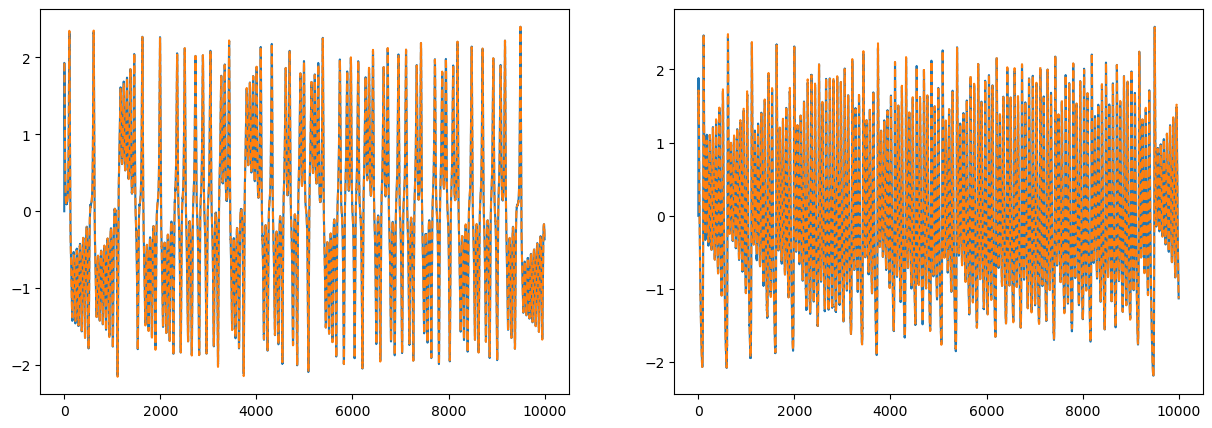

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, xhat_rec_train[:, 0].cpu().numpy())
ax[0].plot(t_train, sup[:nt_train, 0], '--')
ax[1].plot(t_train, xhat_rec_train[:, 2].cpu().numpy())
ax[1].plot(t_train, sup[:nt_train, 2], '--')
plt.show()

In [15]:
nt_test = int(test_time // dt)
s_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
v_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
n_rec_test = torch.zeros((nt_test, n_neurons), device=device, dtype=torch.float32)
x_hat_rec = torch.zeros((nt_test, sup.shape[1]), device=device, dtype=torch.float32)

print(f"Testing Period: {test_time} ms")
for i in tqdm(range(nt_test)):
    ml.euler_step()
    s_rec_test[i] = ml.s[neurons].ravel()
    v_rec_test[i] = ml.v[neurons].ravel()
    n_rec_test[i] = ml.n[neurons].ravel()
    x_hat_rec[i] = ml.x_hat.ravel()

Testing Period: 10000.0 ms


100%|██████████| 99999/99999 [11:30<00:00, 144.75it/s]


In [16]:
save_tensor(s_rec_test, "s_rec_test")
save_tensor(v_rec_test, "v_rec_test")
save_tensor(n_rec_test, "n_rec_test")
save_tensor(x_hat_rec, "x_hat_rec")

Saved s_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved v_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved n_rec_test.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000
Saved x_hat_rec.pt in /home/ali/Code/research/ml_force_research/morris_lecar/results/Q_150_gbar_25_l_1.0_Ne_4000_Ni_1000


In [17]:
ml.dec.abs().max().item()

0.09594909101724625

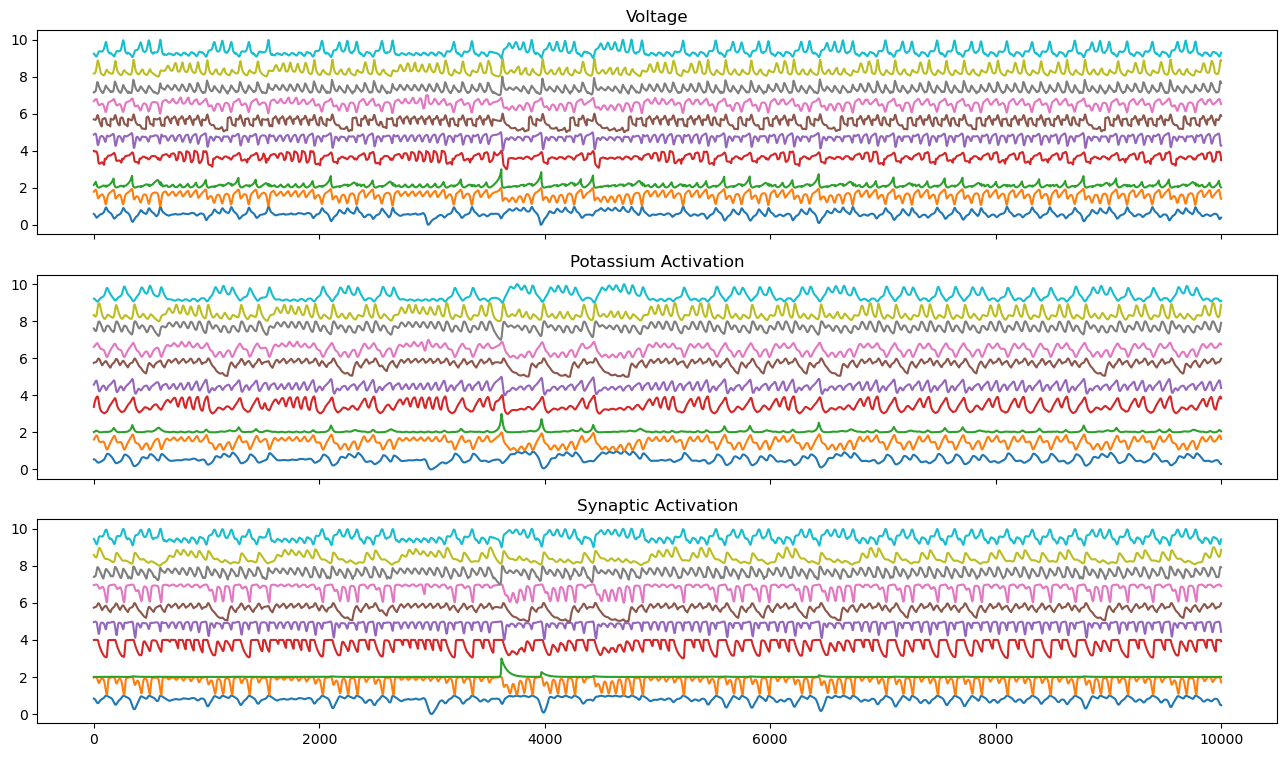

In [18]:
t_test = np.arange(nt_test) * dt + T - test_time

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_train, minmax_transform(v_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_train, minmax_transform(n_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_train, minmax_transform(s_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

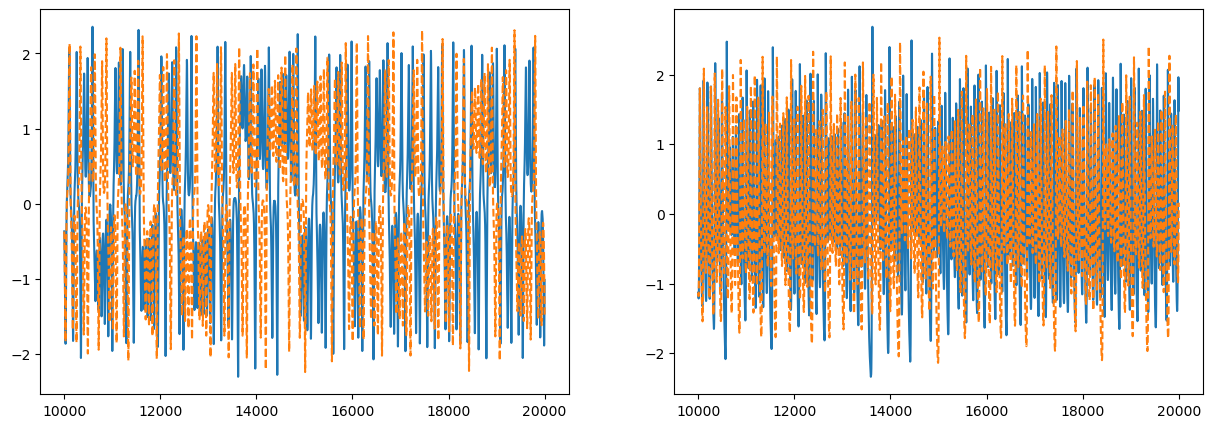

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_test, x_hat_rec[:, 0].cpu().numpy())
ax[0].plot(t_test, sup[nt_train+2:, 0], '--')
ax[1].plot(t_test, x_hat_rec[:, 2].cpu().numpy())
ax[1].plot(t_test, sup[nt_train+2:, 2], '--')
plt.show()

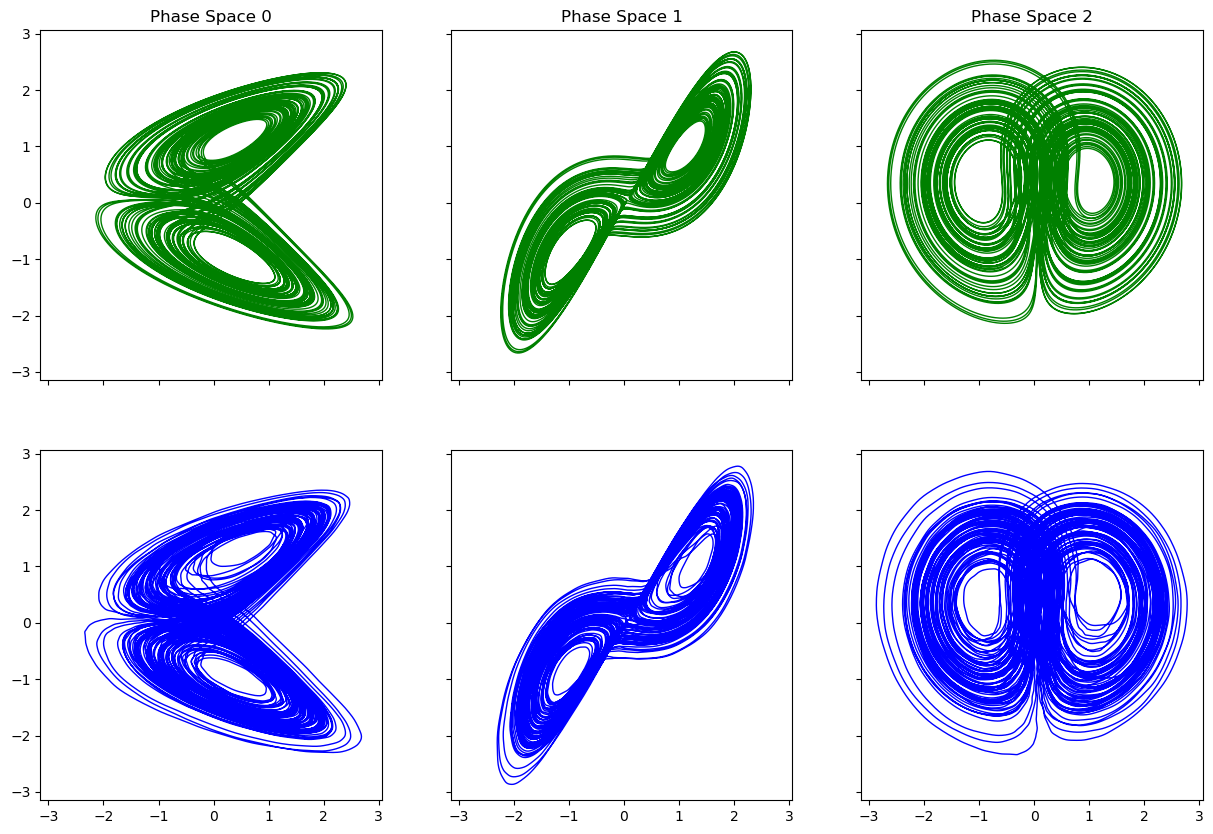

In [20]:
fig, ax = plt.subplots(ncols=ml.sup.shape[1], nrows=2, figsize=(15, 10), sharex=True, sharey=True)
for i in range(ml.sup.shape[1]):
    ax[0, i].plot(sup[nt_train+2:, i-1], sup[nt_train+2:, i], 'g-', lw=1, label="sup")
    ax[1, i].plot(x_hat_rec[:, i-1].cpu().numpy(), x_hat_rec[:, i].cpu().numpy(), 'b-', lw=1, label="out")
    ax[0, i].set_title(f"Phase Space {i}")

# plt.legend()
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_phase_space.png"), dpi=300, bbox_inches='tight')
plt.show()

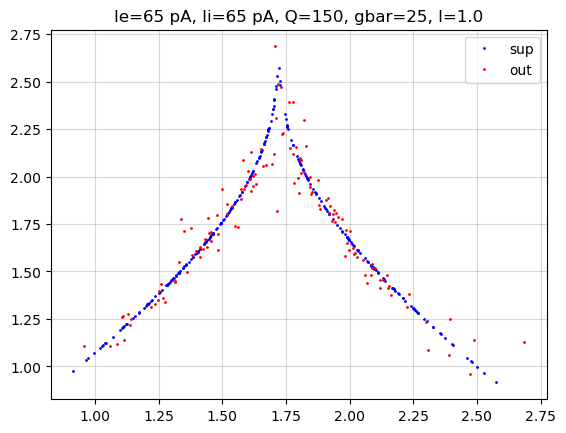

In [22]:

from scipy.signal import find_peaks

z = ml.sup[:, 2].cpu().numpy()
z_hat = x_hat_rec[:, 2].cpu().numpy()

dist = 500

peaks = z[find_peaks(z, distance=dist)[0]]
peaks = peaks[peaks > 0]
peaks_hat = z_hat[find_peaks(z_hat, distance=dist)[0]]
peaks_hat = peaks_hat[peaks_hat > 0]

plt.plot(peaks[:-1], peaks[1:], 'bo', ms=1, label="sup")
plt.plot(peaks_hat[:-1], peaks_hat[1:], 'ro', ms=1, label="out")
# plt.xlim(0.5, 3)
# plt.ylim(0.5, 3)
plt.grid(alpha=.5)
plt.legend()
plt.title(f"Ie={Ie} pA, Ii={Ii} pA, Q={Q}, gbar={gbar}, l={lamda}")
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_return_map_.png"), dpi=300, bbox_inches='tight')
plt.show()

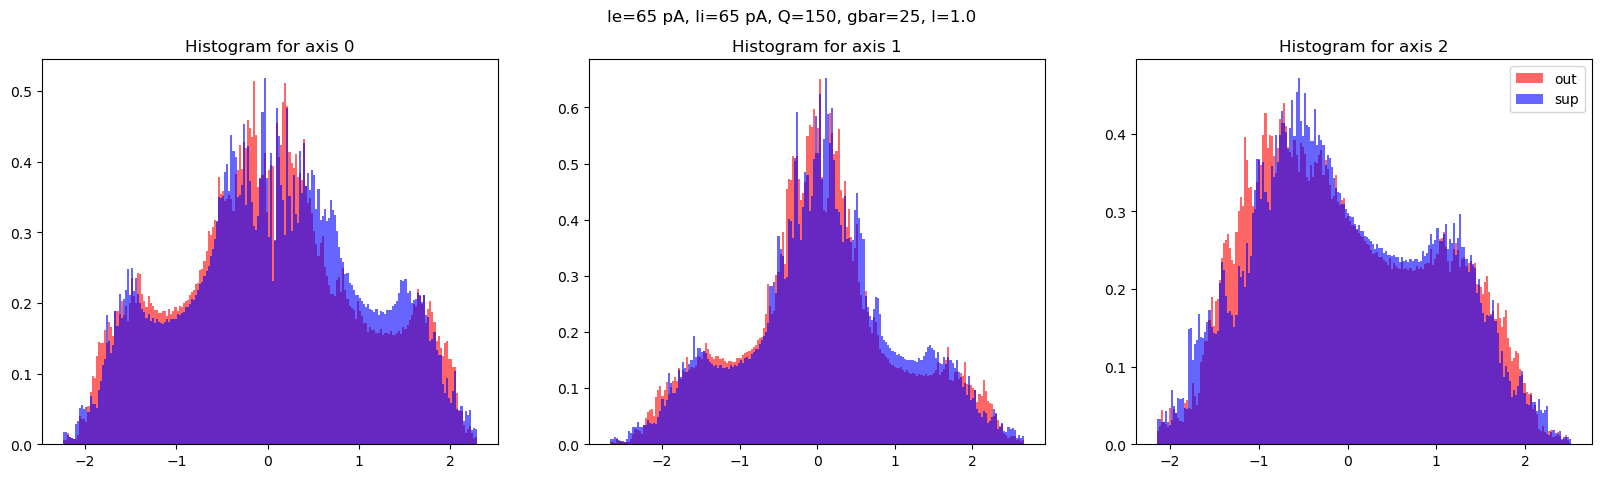

In [23]:
fig, ax = plt.subplots(figsize=(20, 5), ncols=3)

hists = []
for axis in range(len(ax)):
    sup_hist, bins = np.histogram(ml.sup[nt_train:, axis].cpu().numpy(), bins=200, density=True)
    output_hist, bins = np.histogram(x_hat_rec[:, axis].cpu().numpy(), bins=bins, density=True)
    hists.append((sup_hist, output_hist, bins))

    width = bins[1] - bins[0]
    alpha = .6
    ax[axis].bar(bins[:-1], output_hist, width=width, label="out", color='r', alpha=alpha)
    ax[axis].bar(bins[:-1], sup_hist, width=width, label="sup", color='b', alpha=alpha)
    ax[axis].set_title(f"Histogram for axis {axis}")
plt.suptitle(f"Ie={Ie} pA, Ii={Ii} pA, Q={Q}, gbar={gbar}, l={lamda}")
plt.legend()
plt.savefig(os.path.join(save_path, f"N_{ml._N}_ff_{ff_coeff}_histogram.png"), dpi=300, bbox_inches='tight')
plt.show()


In [24]:
for i in range(len(hists)):
    sup_hist, output_hist, bins = hists[i]
    bins = (bins[:-1] + bins[1:]) / 2   # center of the bins
    sup_hist = sup_hist / np.sum(sup_hist)  # normalize
    output_hist = output_hist / np.sum(output_hist) # normalize
    # Mask zeros
    sup_hist = np.where(sup_hist == 0, 1e-10, sup_hist)
    output_hist = np.where(output_hist == 0, 1e-10, output_hist)
    # KL Divergence
    kl_div = np.sum(sup_hist * np.log(sup_hist / output_hist))
    print(f"KL Divergence for axis {i}: {kl_div}")

KL Divergence for axis 0: 0.02308241918690304
KL Divergence for axis 1: 0.02242993534230697
KL Divergence for axis 2: 0.024307782208518196
